# 2. 평가 — 그림 + 통계치 저장 (**5시드 기준**)

`result/predictions/<model>_seed{0..4}.csv` 를 로드해 **시드별로 지표를 계산한 뒤 평균 ± 표준편차**로 보고한다.
- **통계치** → `result/statistics/metrics.csv`(요약), `metrics_by_seed.csv`(원본), `stage_r2.csv`
- **그림** → `result/image/metric_bars.png`, `scatter_grid.png`, `stage_r2.png`

**지표**: R²(설명력), MAE/RMSE(오차, 작을수록↑), MAPE %(상대오차), Spearman ρ(순위 일치도 — 상대가치 랭킹).

> **왜 단일 시드를 쓰지 않는가.** DeepONet 앵커의 시드 표준편차가 최종 R² 기준 **0.0137** 인데,
> 이 노트북이 비교하는 DeepONet 계열의 모델 간 격차는 0.0222(= 1.6 sd) 에 불과하다. 즉 단일 시드
> 숫자로는 순위를 말할 수 없다. 근거는 `scratch/ablation_pi_state.py` →
> `result/statistics/exp_pi_state_ablation.csv` (5시드 × 5 arm, 사다리 전 구간 paired p>0.19).
> 그래서 이 노트북의 **정확도 지표는 전부 5시드**다. 예외는 본문에 단일 시드임을 명시한다.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot
from util.metric import metrics
from util import seeds as sdz
from module import data

# 5시드 예측 CSV 로드 (scratch/run_all_seeds.py, scratch/run_pi_route_seeds.py 산출).
# 가중치→예측 재현 경로(module.infer)는 단일 시드용이라 여기서는 쓰지 않는다.
cfg = utils.load_config()
D = data.load(cfg)
SEEDS = sdz.SEEDS

WANT = ["deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape",
        "deeponet_hybrid_pi_lizard", "xgb_hybrid", "bench_xgboost"]
MODELS = sdz.available(WANT)                 # 시드 CSV 가 5개 다 있는 모델만 (부분 시드 평균은 편향)
MISSING = [m for m in WANT if m not in MODELS]
P = sdz.load(MODELS)                         # {(model, seed): DataFrame}

print(f"시드 {list(SEEDS)} | 5시드 모델 {len(MODELS)}개")
for m in MODELS:
    print(f"   {m}")
if MISSING:
    print(f"제외(시드 CSV 부족) -> {MISSING}")
assert MODELS, "5시드 예측 CSV 가 없다. scratch/run_all_seeds.py 를 먼저 실행하세요."

시드 [0, 1, 2, 3, 4] | 5시드 모델 6개
   deeponet_hybrid
   deeponet_hybrid_l1
   deeponet_hybrid_mape
   deeponet_hybrid_pi_lizard
   xgb_hybrid
   bench_xgboost


In [2]:
# 지표 표 — 시드별 계산 후 평균 ± sd
LM = sdz.long_metrics(P)                                   # model x seed 원본
LM.to_csv(fm.stat("metrics_by_seed"), index=False)
SUM = sdz.summarize(LM)
NOISE = sdz.noise_floor(LM, "R2")

MCOLS = ["R2", "MAPE%", "MdAPE%", "Spearman", "MAE", "RMSE", "Bias%"]
mt = SUM[[f"{c}_mean" for c in MCOLS] + [f"{c}_std" for c in MCOLS]].sort_values("R2_mean", ascending=False)
mt.to_csv(fm.stat("metrics"))

show = pd.DataFrame({c: SUM[f"{c}_mean"].round(4).astype(str) + " ±" + SUM[f"{c}_std"].round(4).astype(str)
                     for c in MCOLS}).loc[mt.index]
print("=== 최종 공정가 OOS 지표 (5시드 평균 ± sd) ===")
print(show.to_string())
print(f"\n노이즈 바닥(모델 내 시드 sd 최댓값, R²) = {NOISE:.4f}")
print("  -> 두 모델의 R² 평균 차이가 이보다 작으면 순위를 주장할 수 없다.")

# plot 헬퍼는 plain 컬럼명을 받으므로 평균만 담은 프레임을 따로 만든다
mt_plain = SUM[[f"{c}_mean" for c in MCOLS]].copy()
mt_plain.columns = MCOLS
mt_plain = mt_plain.loc[mt.index]

# 산점도용: 시드를 합쳐 그린다(같은 상품이 5점 -> 시드 산포가 그림에 보인다)
scat = {m: (pd.concat([P[(m, s)].y_true for s in SEEDS]).values,
            pd.concat([P[(m, s)].y_pred for s in SEEDS]).values) for m in MODELS}

=== 최종 공정가 OOS 지표 (5시드 평균 ± sd) ===
                                       R2           MAPE%          MdAPE%        Spearman             MAE            RMSE            Bias%
model                                                                                                                                     
deeponet_hybrid_mape       0.8042 ±0.0068  1.7601 ±0.0353   1.3852 ±0.032  0.9013 ±0.0058  0.0161 ±0.0003  0.0214 ±0.0004  -0.1681 ±0.1147
deeponet_hybrid_pi_lizard   0.804 ±0.0069  1.7614 ±0.0307   1.386 ±0.0242  0.8997 ±0.0062  0.0162 ±0.0003  0.0214 ±0.0004  -0.1053 ±0.1668
deeponet_hybrid             0.8027 ±0.011  1.7654 ±0.0469  1.3894 ±0.0243  0.8987 ±0.0086  0.0162 ±0.0004  0.0214 ±0.0006    -0.086 ±0.182
deeponet_hybrid_l1         0.8009 ±0.0101  1.7749 ±0.0468  1.3919 ±0.0367  0.8971 ±0.0077  0.0163 ±0.0004  0.0215 ±0.0005  -0.0965 ±0.1536
xgb_hybrid                 0.7929 ±0.0018  1.8042 ±0.0102  1.4145 ±0.0083  0.8923 ±0.0011  0.0165 ±0.0001   0.022 ±0.0001  -0.0342

In [3]:
# stage별 R² (2단계 하이브리드) — 5시드 평균 ± sd
HYB = [m for m in MODELS if "mc_pred" in P[(m, SEEDS[0])].columns]
rows = []
for m in HYB:
    for s in SEEDS:
        d = P[(m, s)]
        rows.append({"model": m, "seed": s,
                     "stage1_MC_R2": metrics(d.mc_true, d.mc_pred)["R2"],
                     "stage2_resid_R2": metrics(d.resid_true, d.resid_pred)["R2"],
                     "final_MC_R2": metrics(d.y_true, d.y_pred)["R2"]})
SL = pd.DataFrame(rows)
SCOLS = ["stage1_MC_R2", "stage2_resid_R2", "final_MC_R2"]
sdf = SL.groupby("model")[SCOLS].mean().loc[[m for m in HYB]]
ssd = SL.groupby("model")[SCOLS].std().loc[[m for m in HYB]]
pd.concat({"mean": sdf, "std": ssd}, axis=1).to_csv(fm.stat("stage_r2"))
print("=== stage별 R² (5시드 평균 ± sd) ===")
print(pd.DataFrame({c: sdf[c].round(3).astype(str) + " ±" + ssd[c].round(3).astype(str)
                    for c in SCOLS}).to_string())
print("\nstage-1 = MC 이론가 앵커 / stage-2 = 공정가 잔차 / final = 공정가")

=== stage별 R² (5시드 평균 ± sd) ===
                           stage1_MC_R2 stage2_resid_R2   final_MC_R2
model                                                                
deeponet_hybrid            0.943 ±0.013    0.612 ±0.015  0.803 ±0.011
deeponet_hybrid_l1         0.945 ±0.012    0.609 ±0.015   0.801 ±0.01
deeponet_hybrid_mape       0.945 ±0.015    0.611 ±0.012  0.804 ±0.007
deeponet_hybrid_pi_lizard  0.945 ±0.022    0.615 ±0.014  0.804 ±0.007
xgb_hybrid                 0.881 ±0.003    0.615 ±0.003  0.793 ±0.002

stage-1 = MC 이론가 앵커 / stage-2 = 공정가 잔차 / final = 공정가


## R² 상세 분석 — 과대평가(overprice) · 구간별 · 시간별

우리 MC는 자산별 **단일 역사변동성**(행사가별 스큐 없음 = 스큐가 평탄)이라 하방 꼬리위험을 과소반영 → 위험(저가) 구간에서 ELS를 **과대평가**하는 경향이 있다. 아래에서 모델별 **과대/과소평가(bias)**, 공정가치 **구간별 R²·MAPE·bias**, **발행시기별 R²**(시간 안정성), 그리고 **잔차-공정가치 곡선**(스큐 평탄화의 흔적)을 분해한다.

In [4]:
# 과대/과소평가(overprice) 분해 — 5시드 평균 ± sd (단위: 원, 발행가 10,000)
FACE = 10000
rows = []
for m in MODELS:
    for s in SEEDS:
        d = P[(m, s)]
        e = (d.y_pred - d.y_true).values
        mm = metrics(d.y_true, d.y_pred)
        rows.append({"model": m, "seed": s, "bias_KRW": e.mean() * FACE,
                     "mae_KRW": np.abs(e).mean() * FACE,
                     "over_share%": (e > 0).mean() * 100,
                     "p95_over_KRW": np.quantile(e, .95) * FACE,
                     "p05_under_KRW": np.quantile(e, .05) * FACE,
                     "R2": mm["R2"], "MAPE%": mm["MAPE%"]})
DL = pd.DataFrame(rows)
DCOLS = ["bias_KRW", "mae_KRW", "over_share%", "p95_over_KRW", "p05_under_KRW", "R2", "MAPE%"]
detdf = DL.groupby("model")[DCOLS].mean().sort_values("bias_KRW")
detsd = DL.groupby("model")[DCOLS].std().loc[detdf.index]
DL.to_csv(fm.stat("bias_by_seed"), index=False)
print("=== 과대/과소평가 분해 (5시드 평균 ± sd) — bias>0 이면 평균적으로 과대평가 ===")
print(pd.DataFrame({c: detdf[c].round(2).astype(str) + " ±" + detsd[c].round(2).astype(str)
                    for c in DCOLS}).to_string())
print("\n우리 MC 는 자산별 단일 역사변동성(행사가별 스큐 없음)이라 하방 꼬리위험을 과소반영한다")
print("-> 위험(저가) 구간에서 ELS 를 과대평가하는 경향. 아래 구간별 분해에서 확인한다.")

=== 과대/과소평가 분해 (5시드 평균 ± sd) — bias>0 이면 평균적으로 과대평가 ===
                                bias_KRW       mae_KRW  over_share%   p95_over_KRW   p05_under_KRW         R2       MAPE%
model                                                                                                                    
bench_xgboost                -82.61 ±0.0   318.42 ±0.0   42.54 ±0.0    567.28 ±0.0    -701.97 ±0.0  0.32 ±0.0   3.44 ±0.0
deeponet_hybrid_mape       -19.77 ±10.42  161.49 ±3.16  45.88 ±1.97  315.23 ±20.41   -357.21 ±8.41  0.8 ±0.01  1.76 ±0.04
deeponet_hybrid_pi_lizard   -14.25 ±15.1  161.52 ±2.64  46.64 ±2.67   323.7 ±27.16  -349.35 ±14.62  0.8 ±0.01  1.76 ±0.03
deeponet_hybrid_l1         -13.48 ±13.92  162.77 ±4.17   46.8 ±2.34  328.07 ±30.63  -352.04 ±12.19  0.8 ±0.01  1.77 ±0.05
deeponet_hybrid            -12.43 ±16.51  161.92 ±4.05  47.08 ±2.57  325.43 ±35.31  -348.82 ±14.67  0.8 ±0.01  1.77 ±0.05
xgb_hybrid                   -7.94 ±2.33  165.37 ±0.91  48.51 ±0.61   330.32 ±3.18   -359.

In [5]:
# 공정가치 구간별 · 발행시기별 R² 분해 — 5시드 평균 ± sd
KEY = [m for m in ["deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape",
                   "deeponet_hybrid_pi_lizard", "xgb_hybrid", "bench_xgboost"] if m in MODELS]
ref = P[(KEY[0], SEEDS[0])]
fair0 = ref.y_true.values; ord0 = ref.isu_ord.values
q = np.quantile(fair0, [1/3, 2/3])
segs = ["low(위험/저가)", "mid", "high(안전/고가)"]
tb = np.quantile(ord0, [.25, .5, .75])

rows = []
for m in KEY:
    for s in SEEDS:
        d = P[(m, s)]
        yt = d.y_true.values; yp = d.y_pred.values
        seg = np.where(yt <= q[0], segs[0], np.where(yt <= q[1], segs[1], segs[2]))
        for g in segs:
            k = seg == g; e = yp[k] - yt[k]
            rows.append({"model": m, "seed": s, "axis": "fair_segment", "group": g, "n": int(k.sum()),
                         "R2": metrics(yt[k], yp[k])["R2"],
                         "MAPE%": float(np.mean(np.abs(e) / np.abs(yt[k])) * 100),
                         "bias_KRW": float(e.mean() * FACE)})
        tbin = np.digitize(d.isu_ord.values, tb)
        for b in range(4):
            k = tbin == b; e = yp[k] - yt[k]
            rows.append({"model": m, "seed": s, "axis": "issue_period", "group": f"P{b}", "n": int(k.sum()),
                         "R2": metrics(yt[k], yp[k])["R2"],
                         "MAPE%": float(np.mean(np.abs(e) / np.abs(yt[k])) * 100),
                         "bias_KRW": float(e.mean() * FACE)})
SEG = pd.DataFrame(rows)
SEG.to_csv(fm.stat("segment_by_seed"), index=False)

for axis, title in [("fair_segment", "공정가치 3분위 구간별"), ("issue_period", "발행시기 4구간별 (P0=과거→P3=최근)")]:
    A = SEG[SEG.axis == axis]
    mu = A.pivot_table(index="model", columns="group", values="R2", aggfunc="mean").loc[KEY]
    sg = A.pivot_table(index="model", columns="group", values="R2", aggfunc="std").loc[KEY]
    print(f"=== {title}  R² (5시드 평균 ± sd) ===")
    print(pd.DataFrame({c: mu[c].round(3).astype(str) + " ±" + sg[c].round(3).astype(str)
                        for c in mu.columns}).to_string())
    print()

=== 공정가치 3분위 구간별  R² (5시드 평균 ± sd) ===
                             high(안전/고가)    low(위험/저가)            mid
model                                                                
deeponet_hybrid            -0.735 ±0.056  0.297 ±0.096  -0.948 ±0.071
deeponet_hybrid_l1         -0.758 ±0.075  0.294 ±0.073    -0.97 ±0.12
deeponet_hybrid_mape       -0.746 ±0.053   0.318 ±0.05  -0.964 ±0.057
deeponet_hybrid_pi_lizard   -0.74 ±0.053  0.299 ±0.071  -0.904 ±0.033
xgb_hybrid                 -0.842 ±0.016  0.263 ±0.011  -1.022 ±0.037
bench_xgboost                -7.894 ±0.0   -0.772 ±0.0    -4.237 ±0.0

=== 발행시기 4구간별 (P0=과거→P3=최근)  R² (5시드 평균 ± sd) ===
                                     P0            P1            P2            P3
model                                                                            
deeponet_hybrid            0.809 ±0.006  0.627 ±0.075   0.73 ±0.012   0.529 ±0.01
deeponet_hybrid_l1         0.809 ±0.003  0.625 ±0.059  0.718 ±0.014  0.534 ±0.012
deeponet_hybrid_mape  

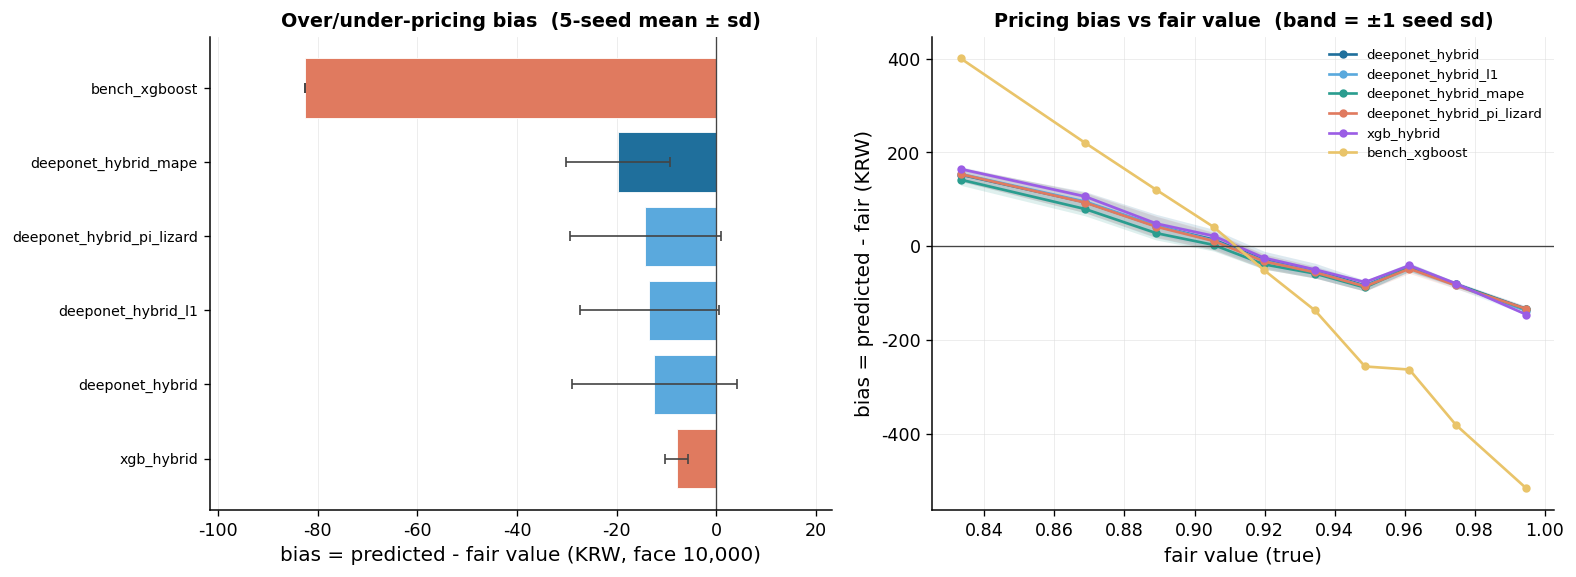

saved -> error_analysis.png   (bias = predicted - fair value, 5시드 평균 ± sd)


In [6]:
# 그림: (1) 모델별 과대/과소 bias  (2) bias vs 공정가 곡선 (스큐 평탄화 흔적)  [5시드]
from util import plot as _plot
fig, ax = plt.subplots(1, 2, figsize=(13.333, 5.0))

# ① bias 막대 + 시드 오차봉
mm = detdf.sort_values("bias_KRW")
y = np.arange(len(mm))
ax[0].barh(y, mm["bias_KRW"].values, xerr=detsd.loc[mm.index, "bias_KRW"].values,
           color=[_plot.model_color(x) for x in mm.index], edgecolor="white", linewidth=.5,
           error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
ax[0].set_yticks(y); ax[0].set_yticklabels(mm.index, fontsize=8.5); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=.8)
ax[0].set_xlabel("bias = predicted - fair value (KRW, face 10,000)")
ax[0].set_title("Over/under-pricing bias  (5-seed mean ± sd)", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=.5, alpha=.6); ax[0].margins(x=.22)

# ② bias vs 공정가: 시드마다 곡선을 만들고 평균 ± sd 밴드
for j, name in enumerate(KEY):
    curves = []
    for s in SEEDS:
        d = P[(name, s)]; yt = d.y_true.values; yp = d.y_pred.values
        bins = np.quantile(yt, np.linspace(0, 1, 11))
        ib = np.clip(np.digitize(yt, bins[1:-1]), 0, 9)
        curves.append([(yp[ib == k] - yt[ib == k]).mean() * FACE for k in range(10)])
        xc = [yt[ib == k].mean() for k in range(10)]
    cur = np.array(curves); mu = cur.mean(0); sg = cur.std(0)
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[1].plot(xc, mu, marker="o", ms=4, lw=1.6, color=c, label=name)
    ax[1].fill_between(xc, mu - sg, mu + sg, color=c, alpha=.15, linewidth=0)
ax[1].axhline(0, color="#444", lw=.8)
ax[1].set_xlabel("fair value (true)"); ax[1].set_ylabel("bias = predicted - fair (KRW)")
ax[1].set_title("Pricing bias vs fair value  (band = ±1 seed sd)", fontsize=11.5)
ax[1].grid(color="#dddddd", lw=.5, alpha=.6); ax[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(fm.image("error_analysis"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved -> error_analysis.png   (bias = predicted - fair value, 5시드 평균 ± sd)")

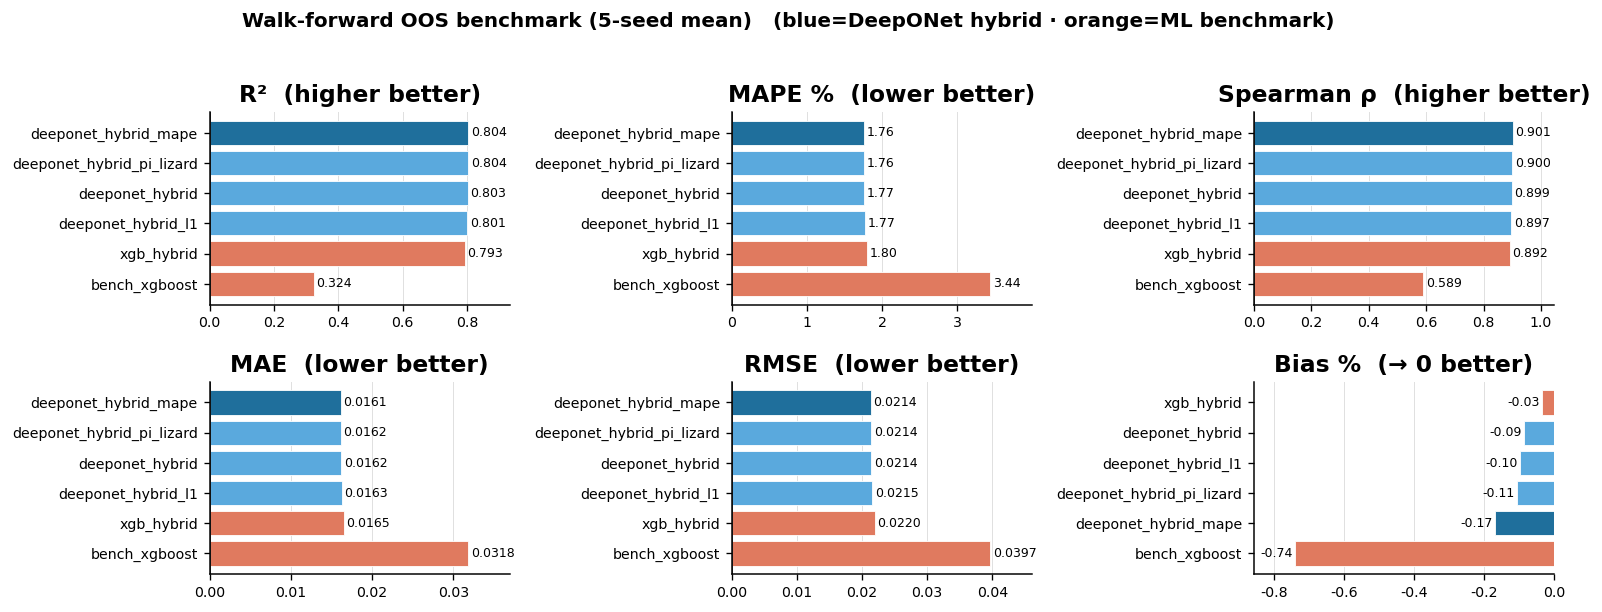

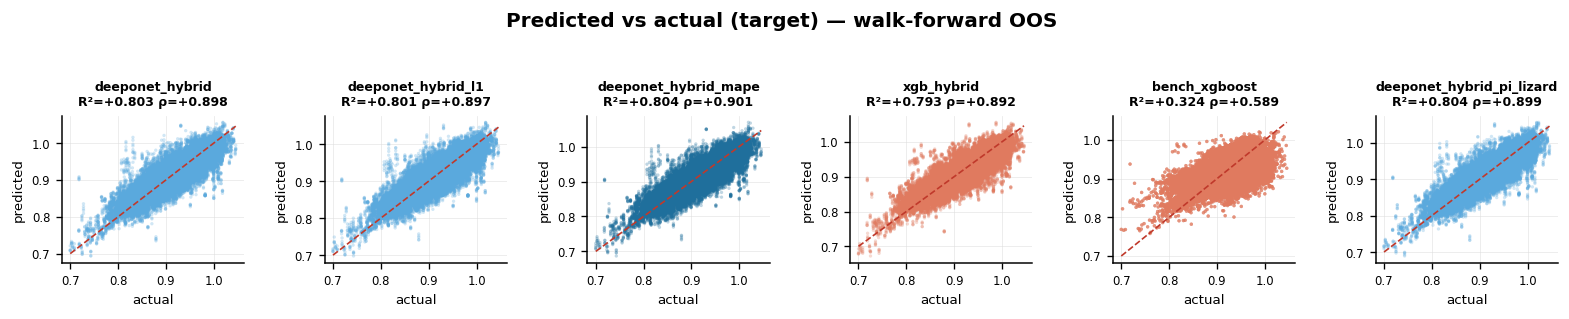

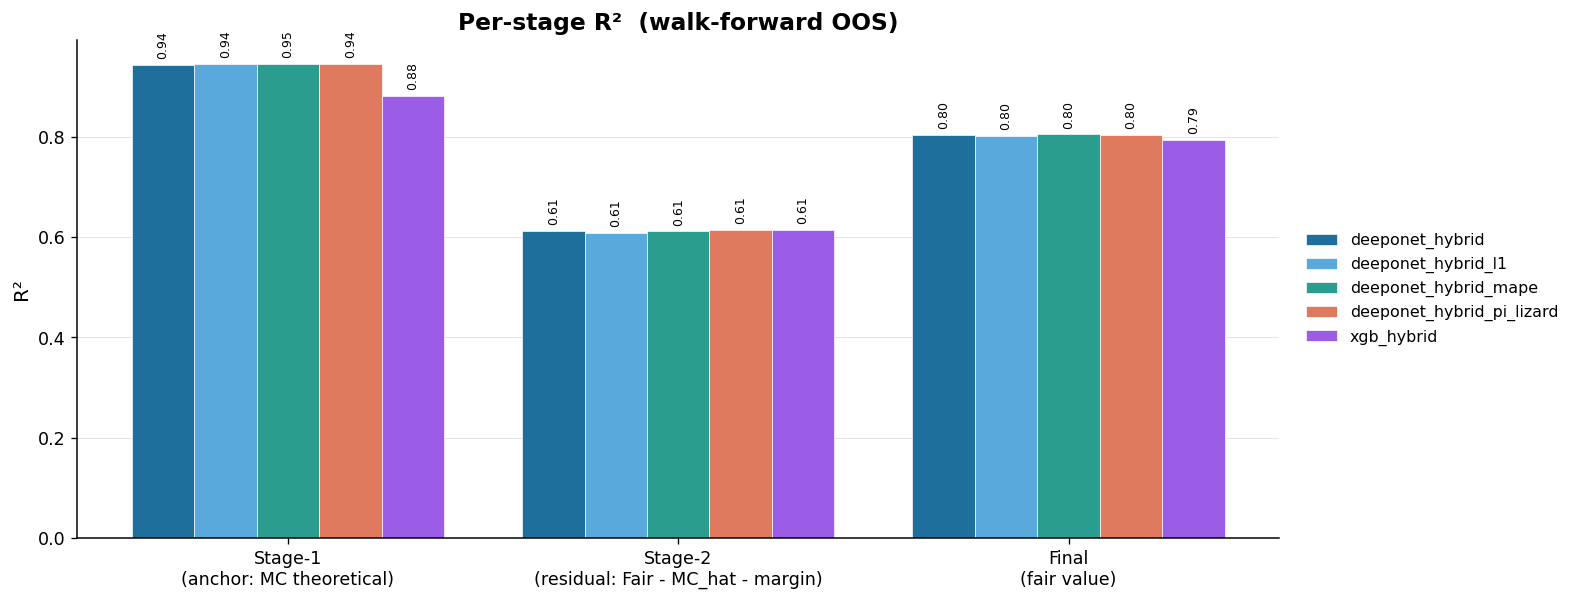

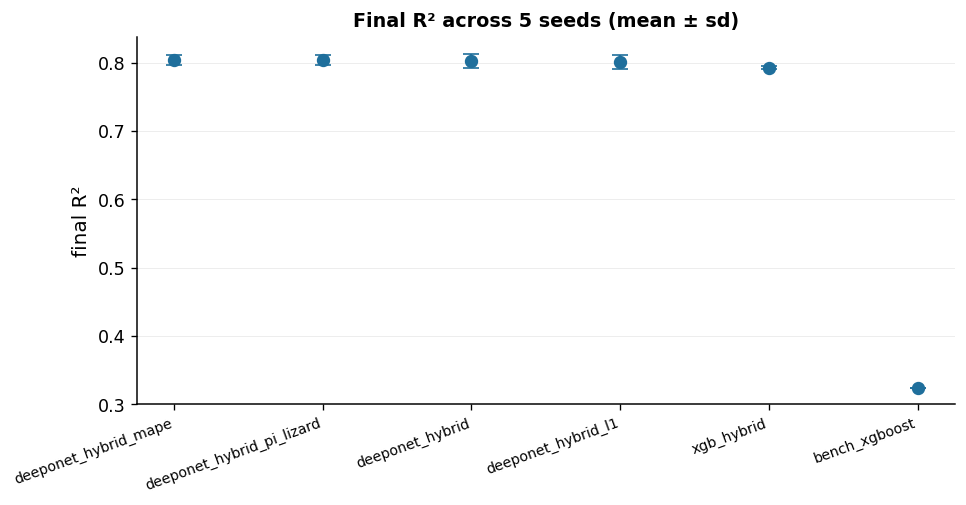

saved images -> ['ablation_lizard_cols.png', 'ablation_stage2_features.png', 'bakeoff_mae_ranking.png', 'bakeoff_mechanism.png', 'bakeoff_track2_solver.png', 'bates2_ablation.png', 'bates_vs_hist_overview.png', 'bates_vs_hist_segment.png'] ...
saved stats  -> ['ablation_lizard_cols.csv', 'ablation_stage2_features.csv', 'anchor_bates_hv252.csv', 'bakeoff_track1_3.csv', 'bates2_ablation_A0.csv', 'bates2_ablation_A1.csv', 'bates2_ablation_A2.csv', 'bates_expanded_metrics.csv'] ...


In [7]:
# 그림 저장 + 표시 (모든 막대는 5시드 평균; 산점도는 5시드 전부를 겹쳐 그린다)
ORDER = ["deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape",
         "deeponet_hybrid_pi", "xgb_hybrid", "bench_xgboost"]
order = [m for m in ORDER if m in scat] + [m for m in scat if m not in ORDER]

plot.metric_bars(mt_plain, fm.image("metric_bars"),
                 title="Walk-forward OOS benchmark (5-seed mean)")
plot.scatter_grid(scat, order=order, path=fm.image("scatter_grid"))
if len(sdf):
    plot.stage_r2_bar(sdf, fm.image("stage_r2"))
plt.show()

# 5시드 산포를 한 장에: 최종 R² 오차봉
fig, a = plt.subplots(figsize=(plot.SLIDE_W * .62, 4.4))
o = SUM["R2_mean"].sort_values(ascending=False).index
a.errorbar(range(len(o)), SUM.loc[o, "R2_mean"], yerr=SUM.loc[o, "R2_std"],
           fmt="o", ms=7, capsize=5, lw=1.4, color="#1f6f9c")
a.set_xticks(range(len(o))); a.set_xticklabels(o, rotation=20, ha="right", fontsize=8.5)
a.set_ylabel("final R²"); a.set_title("Final R² across 5 seeds (mean ± sd)", fontsize=11.5)
a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("metric_seed_spread"), dpi=400,
                                bbox_inches="tight", transparent=True)
plt.show()
print("saved images ->", [p.name for p in sorted(fm.IMAGE.glob("*.png"))][:8], "...")
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("*.csv"))][:8], "...")

## 4구조별 · 기초자산별 성능 — 통합 모델 하나로 전 구조를 커버하는가

유니버스가 STEP/LIZARD × 낙인/노낙인 4구조로 넓어졌고 **모델은 하나**다. 전체 R² 만 보면 STEP-낙인이
표본의 약 39%를 차지해 다른 구조의 열화가 가려지므로, 구조별·기초자산 조합별로 쪼개서 본다.
기초자산 조합은 고유 239개 중 표본 100건 이상만 개별 표기하고 나머지는 `(small)` 로 합친다.

In [8]:
# 4구조별 · 기초자산별 성능 분해 — 5시드 평균 ± sd
from util.metric import metrics_by
src = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn", "udl_key"]].copy()
src["struct"] = src["opt_type"] + " x " + np.where(src["ki_yn"] == 1, "KI", "no-KI")
src = src.rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str}).set_index("ITEM_CD")

GKEY = [m for m in ["deeponet_hybrid", "deeponet_hybrid_mape", "deeponet_hybrid_pi_lizard",
                    "xgb_hybrid", "bench_xgboost"] if m in MODELS]


def joined(m, s):
    d = P[(m, s)].copy()
    d["ITEM_CD"] = d["ITEM_CD"].astype(str)
    d = d.join(src, on="ITEM_CD")
    assert d["struct"].notna().all(), f"{m}/{s}: parquet 조인 실패 (ITEM_CD 불일치)"
    return d


rows_s, rows_u = [], []
for m in GKEY:
    for s in SEEDS:
        d = joined(m, s)
        for lab, sub in d.groupby("struct"):
            rows_s.append({"model": m, "seed": s, "group": lab, "n": len(sub),
                           **{k: v for k, v in metrics(sub.y_true, sub.y_pred).items()}})
        t = metrics_by(d.y_true, d.y_pred, d.udl_key, min_n=100)
        for lab, r in t.iterrows():
            rows_u.append({"model": m, "seed": s, "group": lab, **r.to_dict()})
BSL = pd.DataFrame(rows_s); BUL = pd.DataFrame(rows_u)
BSL.to_csv(fm.stat("metrics_by_structure_seed"), index=False)
BUL.to_csv(fm.stat("metrics_by_underlying_seed"), index=False)

SHOW = ["R2", "MAPE%", "Bias%", "Spearman"]
BS = BSL.groupby(["model", "group"])[["n"] + SHOW].mean()
BSsd = BSL.groupby(["model", "group"])[SHOW].std()
BU = BUL.groupby(["model", "group"])[["n"] + SHOW].mean()
BUsd = BUL.groupby(["model", "group"])[SHOW].std()
BS.to_csv(fm.stat("metrics_by_structure")); BU.to_csv(fm.stat("metrics_by_underlying"))
print("=== 4구조별 (5시드 평균 ± sd) ===")
print(pd.DataFrame({"n": BS["n"].astype(int).astype(str),
                    **{c: BS[c].round(3).astype(str) + " ±" + BSsd[c].round(3).astype(str)
                       for c in SHOW}}).to_string())
print("\n=== 기초자산 조합별 (n>=100, 5시드 평균 ± sd) ===")
print(pd.DataFrame({"n": BU["n"].astype(int).astype(str),
                    **{c: BU[c].round(3).astype(str) + " ±" + BUsd[c].round(3).astype(str)
                       for c in ["R2", "MAPE%"]}}).to_string())
# 대표 모델 = 목록 첫 번째 (그림용)
bs = {m: BS.loc[m] for m in GKEY}; bu = {m: BU.loc[m] for m in GKEY}
bs_sd = {m: BSsd.loc[m] for m in GKEY}; bu_sd = {m: BUsd.loc[m] for m in GKEY}

=== 4구조별 (5시드 평균 ± sd) ===
                                              n            R2         MAPE%          Bias%      Spearman
model                     group                                                                         
bench_xgboost             LIZARD x KI       655    0.269 ±0.0    4.715 ±0.0    -1.477 ±0.0    0.343 ±0.0
                          LIZARD x no-KI   1858    0.239 ±0.0    4.125 ±0.0    -1.025 ±0.0    0.494 ±0.0
                          STEP x KI        8708    0.177 ±0.0    3.952 ±0.0    -0.995 ±0.0    0.465 ±0.0
                          STEP x no-KI    12295    0.461 ±0.0    2.907 ±0.0    -0.474 ±0.0    0.706 ±0.0
deeponet_hybrid           LIZARD x KI       655  0.837 ±0.007  2.024 ±0.056  -0.423 ±0.089   0.87 ±0.008
                          LIZARD x no-KI   1858  0.773 ±0.009  2.142 ±0.047   -0.678 ±0.25  0.887 ±0.008
                          STEP x KI        8708  0.783 ±0.011  1.902 ±0.045  -0.094 ±0.213  0.886 ±0.009
                          ST

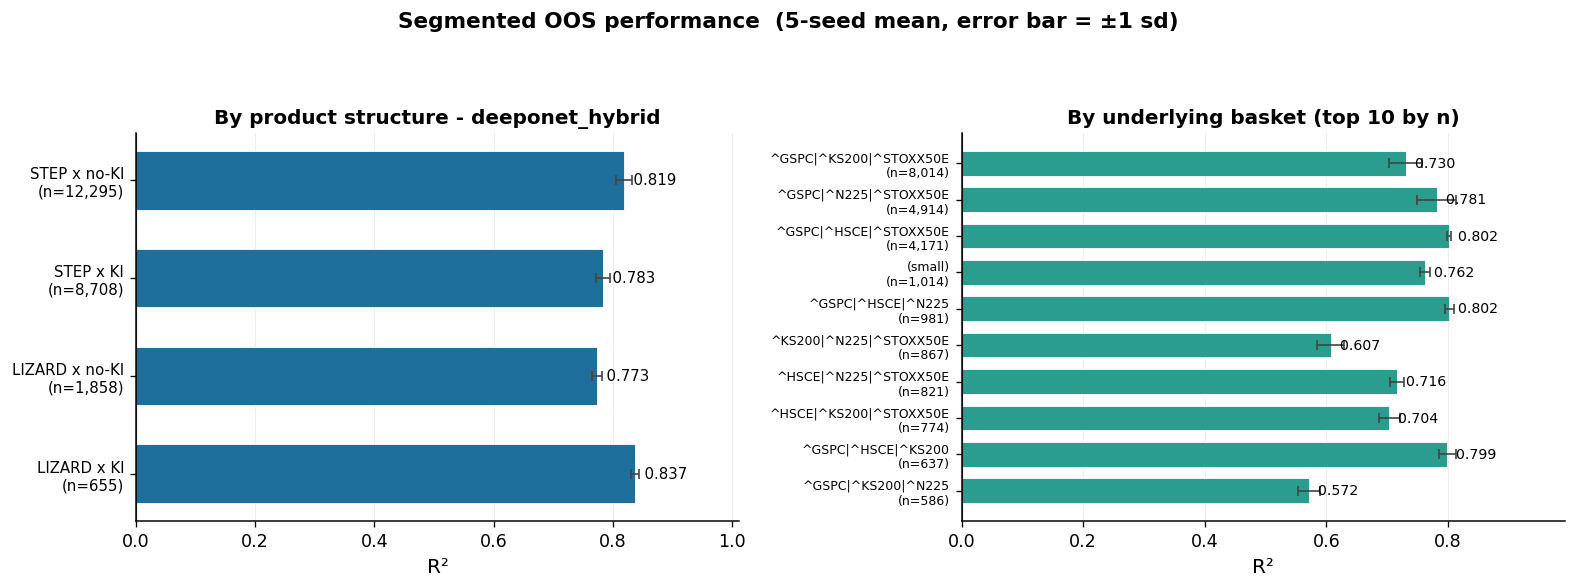

saved -> metrics_by_group.png


In [9]:
# 그림: 구조별 R² · 기초자산 조합별 R² (상위 10 조합) — 5시드 평균 ± sd 오차봉
from util import plot as _plot
best = GKEY[0]                                        # 대표 모델 = 목록 첫 번째
S = bs[best].sort_values("n", ascending=False)
Ssd = bs_sd[best].loc[S.index]
U = bu[best].sort_values("n", ascending=False).head(10)
Usd = bu_sd[best].loc[U.index]

fig, ax = plt.subplots(1, 2, figsize=(13.333, 5.0))
y = np.arange(len(S))
ax[0].barh(y, S["R2"].values, height=0.6, xerr=Ssd["R2"].values, color="#1f6f9c",
           edgecolor="white", linewidth=0.5, error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
ax[0].set_yticks(y)
ax[0].set_yticklabels([f"{i}\n(n={int(n):,})" for i, n in zip(S.index, S["n"])], fontsize=9)
ax[0].invert_yaxis(); ax[0].axvline(0, color="#444", lw=0.7)
for i, v in enumerate(S["R2"].values):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=9)
ax[0].set_xlabel("R²"); ax[0].set_title(f"By product structure - {best}", fontsize=12)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.20)

y2 = np.arange(len(U))
ax[1].barh(y2, U["R2"].values, height=0.68, xerr=Usd["R2"].values, color="#2a9d8f",
           edgecolor="white", linewidth=0.5, error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
ax[1].set_yticks(y2)
ax[1].set_yticklabels([f"{str(i)[:28]}\n(n={int(n):,})" for i, n in zip(U.index, U["n"])], fontsize=7.5)
ax[1].invert_yaxis(); ax[1].axvline(0, color="#444", lw=0.7)
for i, v in enumerate(U["R2"].values):
    ax[1].text(v, i, f"  {v:.3f}", va="center", fontsize=8.5)
ax[1].set_xlabel("R²"); ax[1].set_title("By underlying basket (top 10 by n)", fontsize=12)
ax[1].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[1].margins(x=0.22)

fig.suptitle("Segmented OOS performance  (5-seed mean, error bar = ±1 sd)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("metrics_by_group"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("metrics_by_group").name)

                         kind     n  batch_ms  per_product_us  products_per_sec
model                                                                          
deeponet_hybrid_s2don  hybrid  5879      1.68            0.29        3508593.91
deeponet_hybrid_l1     hybrid  5879      4.13            0.70        1424711.31
deeponet_hybrid        hybrid  5879      4.15            0.71        1416421.72
deeponet_hybrid_mape   hybrid  5879      4.21            0.72        1397648.79
bench_catboost         direct  5879      4.55            0.77        1292158.92
xgb_hybrid             hybrid  5879      6.41            1.09         917740.54
bench_xgboost          direct  5879     10.48            1.78         560794.02
bench_ridge            direct  5879     11.64            1.98         505060.05
bench_lgbm             direct  5879     21.94            3.73         267901.90
bench_gbm              direct  5879     23.17            3.94         253734.92


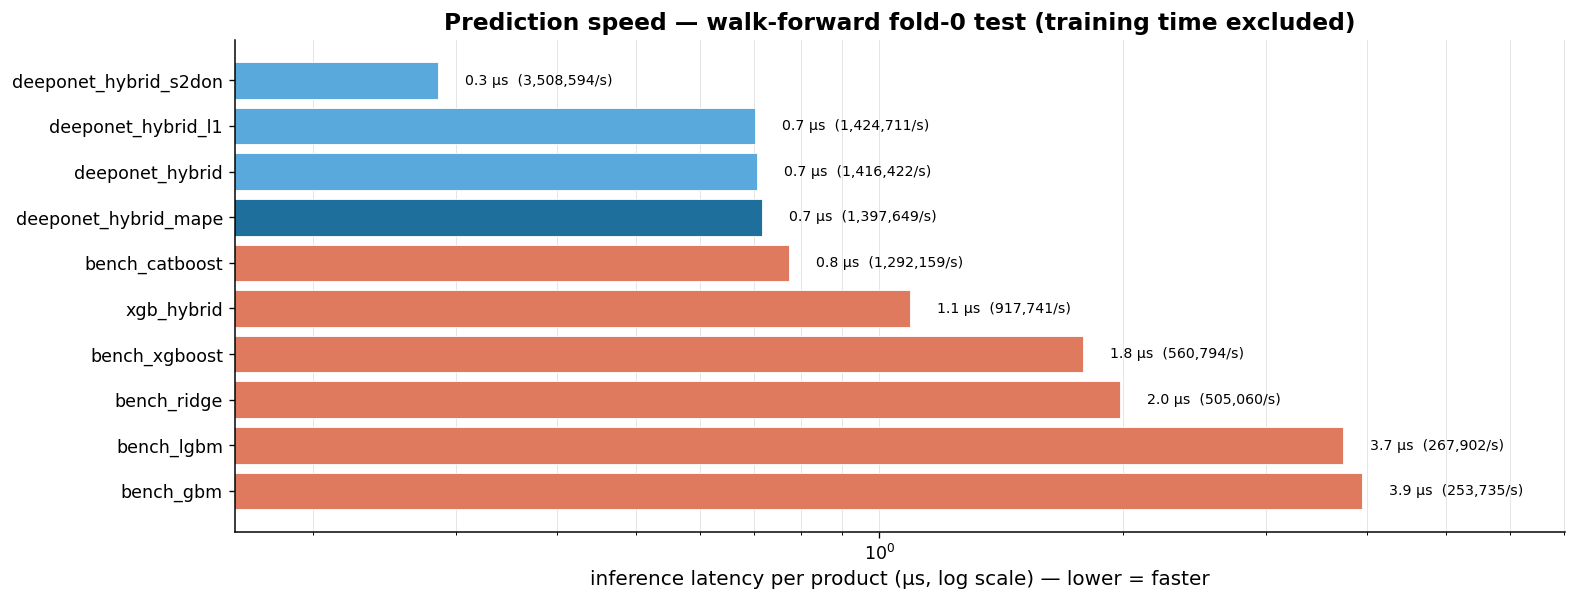

saved -> inference_speed.png | inference_speed.csv


In [10]:
# 예측(추론) 속도 측정 + 그래프  (학습 시간 제외, fold-0 test 기준)
from util import utils, speed
from module import data as _data
cfg = utils.load_config()
Dspd = _data.load(cfg)
spd = speed.measure(Dspd, cfg)
spd.to_csv(fm.stat("inference_speed"))
print(spd.round(2).to_string())
plot.speed_bar(spd, fm.image("inference_speed"))
plt.show()
print("saved ->", fm.image("inference_speed").name, "|", fm.stat("inference_speed").name)

## 라우팅 하이브리드 — LIZARD no-KI 만 물리(PDE) 앵커 (`deeponet_hybrid_pi_lizard`)

물리 제약을 **전 구조에 일괄 적용하면** stage-1 이 STEP 에서 나빠지고 LIZARD 에서만 좋아졌다
(5_segment 5-1b). STEP 은 표본 8.7k~12.3k 에 stage-1 R² 가 이미 0.96~0.97 로 포화라 물리 prior 가
편향만 더하고, LIZARD no-KI 는 표본 1.9k 에 stage-1 이 0.84 에 그쳐 여지가 있다. 그래서 폴드마다
앵커 두 개를 전체 train 으로 학습하고 **예측 단계에서 계약 조건으로 갈라 쓴다**.

- **branch A** (그 외 구조) — `PIStateDeepONet` trunk 61 + state 마스킹 0. 기능적으로 DeepONet 이고,
  trunk fan_in 이 61 이라 Kaiming bound 가 작아져 **시드 분산이 준다**(실측 R² sd 0.0118 → 0.0031).
- **branch B** (LIZARD no-KI) — 같은 망 + state 활성 + PDE 잔차, branch A 체크포인트에서 커리큘럼 초기화.

라우팅 키는 `module.pi_train.lizard_no_ki_mask` — `lz_barr_j < 1.15` 중 하나라도 참(LIZARD) AND
`B >= 1`(no-KI). parquet 의 `opt_type`·`ki_yn` 과 58,790건 전부 일치하므로 **계약서만으로 유도되고
누출이 없다**. 라우팅 후 stage-2 는 하나만 올린다.

아래 셀의 대조군 `control_norouting` 은 **같은 branch A 가중치**로 라우팅만 끈 것이다 — 시드·초기화·
학습데이터가 동일한 짝지은 대조군이라 라우팅 효과만 분리된다.


In [11]:
# 라우팅 효과: 짝지은 대조군(control_norouting)과 5시드 비교
ROUTE = "deeponet_hybrid_pi_lizard"
rp = fm.stat("exp_pi_route_seeds")
if ROUTE not in MODELS or not rp.exists():
    print(f"건너뜀 — {ROUTE} 5시드 결과 없음 (scratch/run_pi_route_seeds.py 실행 필요)")
else:
    RS = pd.read_csv(rp)
    A = RS[RS.scope == "all"]
    agg = A.groupby("model").agg(stage1_mean=("stage1_R2", "mean"), stage1_sd=("stage1_R2", "std"),
                                 final_mean=("final_R2", "mean"), final_sd=("final_R2", "std"),
                                 rmse_mean=("final_RMSE", "mean"), rmse_sd=("final_RMSE", "std"))
    print("=== 집계 (5시드 평균 ± sd) ===")
    print(agg.round(5).to_string())

    piv = A.pivot(index="seed", columns="model", values="final_R2")
    dd = piv["routed"] - piv["control_norouting"]
    print("\n=== 짝지은 차이 (routed - control_norouting), 같은 branch A 가중치 공유 ===")
    print(dd.round(5).to_string())
    print(f"  mean={dd.mean():+.5f}  sd={dd.std():.5f}  se={dd.std()/np.sqrt(len(dd)):.5f}  "
          f"이긴 시드 {int((dd>0).sum())}/{len(dd)}")
    print(f"  노이즈 바닥(R² 시드 sd) = {NOISE:.5f}  -> |mean| 이 이보다 작으면 해석 불가")

    print("\n=== 구조별 stage-1 R² (라우팅이 목표한 지점, 5시드 평균 ± sd) ===")
    ST = RS[RS.scope != "all"]
    mu = ST.pivot_table(index="scope", columns="model", values="stage1_R2", aggfunc="mean")
    sg = ST.pivot_table(index="scope", columns="model", values="stage1_R2", aggfunc="std")
    order = ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
    order = [o for o in order if o in mu.index]
    print(pd.DataFrame({c: mu.loc[order, c].round(4).astype(str) + " ±" + sg.loc[order, c].round(4).astype(str)
                        for c in mu.columns}).to_string())
    print("\n  LIZARD no-KI 만 branch B(PI+PDE) 를 쓰므로 그 행에서만 두 모델이 달라야 한다.")

=== 집계 (5시드 평균 ± sd) ===
                   stage1_mean  stage1_sd  final_mean  final_sd  rmse_mean  rmse_sd
model                                                                              
control_norouting      0.94454    0.02224     0.80272   0.00770    0.02145  0.00042
routed                 0.94463    0.02166     0.80398   0.00686    0.02138  0.00037

=== 짝지은 차이 (routed - control_norouting), 같은 branch A 가중치 공유 ===
seed
0    0.00043
1    0.00318
2    0.00006
3    0.00210
4    0.00055
  mean=+0.00126  sd=0.00133  se=0.00059  이긴 시드 5/5
  노이즈 바닥(R² 시드 sd) = 0.01097  -> |mean| 이 이보다 작으면 해석 불가

=== 구조별 stage-1 R² (라우팅이 목표한 지점, 5시드 평균 ± sd) ===
               control_norouting          routed
scope                                           
STEP x KI         0.9515 ±0.0113  0.9515 ±0.0113
STEP x no-KI      0.9499 ±0.0408  0.9499 ±0.0408
LIZARD x KI       0.9324 ±0.0156  0.9324 ±0.0156
LIZARD x no-KI     0.8562 ±0.061  0.8575 ±0.0558

  LIZARD no-KI 만 branch B(PI+PDE) 를 쓰므로 그 행에서만 두 모델

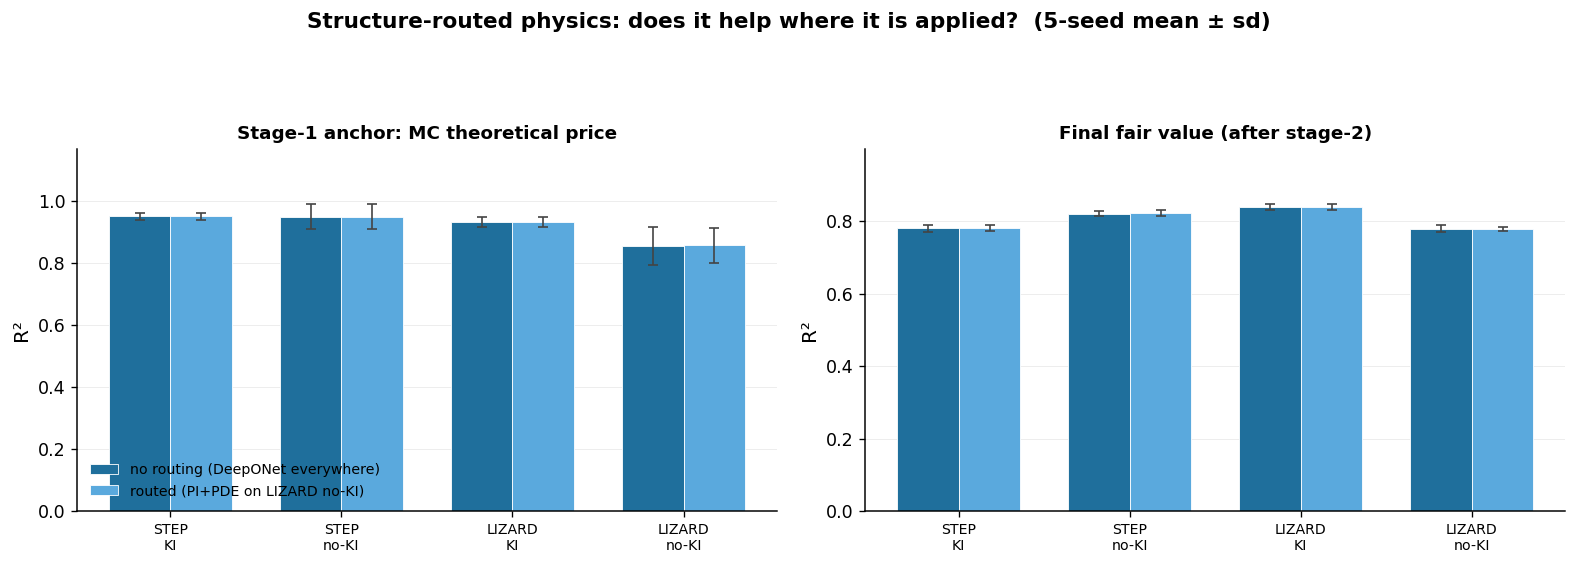

saved -> pi_route_structure.png


In [12]:
# 그림: 라우팅 효과 (구조별 stage-1 / 최종, 5시드 평균 ± sd)
if ROUTE in MODELS and fm.stat("exp_pi_route_seeds").exists():
    ST = RS[RS.scope != "all"]
    order = [o for o in ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"] if o in set(ST.scope)]
    fig, ax = plt.subplots(1, 2, figsize=(plot.SLIDE_W, 4.8))
    x = np.arange(len(order)); w = .36
    NLAB = {"control_norouting": "no routing (DeepONet everywhere)", "routed": "routed (PI+PDE on LIZARD no-KI)"}
    for panel, col, ttl in [(0, "stage1_R2", "Stage-1 anchor: MC theoretical price"),
                            (1, "final_R2", "Final fair value (after stage-2)")]:
        mu = ST.pivot_table(index="scope", columns="model", values=col, aggfunc="mean").loc[order]
        sg = ST.pivot_table(index="scope", columns="model", values=col, aggfunc="std").loc[order]
        for j, mdl in enumerate(["control_norouting", "routed"]):
            ax[panel].bar(x + (j - .5) * w, mu[mdl].values, w, yerr=sg[mdl].values,
                          label=NLAB[mdl], color=plot._QUAL[j], edgecolor="white", linewidth=.5,
                          error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
        ax[panel].set_xticks(x)
        ax[panel].set_xticklabels([o.replace(" x ", "\n") for o in order], fontsize=8.5)
        ax[panel].set_ylabel("R²"); ax[panel].set_title(ttl, fontsize=11)
        ax[panel].grid(axis="y", color="#dddddd", lw=.5, alpha=.6); ax[panel].margins(y=.18)
    ax[0].legend(fontsize=8.5, loc="lower left")
    fig.suptitle("Structure-routed physics: does it help where it is applied?  (5-seed mean ± sd)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.savefig(fm.image("pi_route_structure"), dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    print("saved -> pi_route_structure.png")
else:
    print("건너뜀 — 라우팅 5시드 결과 없음")

## 공정가 예측 세분화 — 신뢰구간 모델 (`deeponet_hybrid_ci`)

`deeponet_hybrid_ci`(가우시안 NLL) 예측을 **세분화**해 발표용 그림을 저장한다.
- **예측±CI 밴드** (`mc_pred_ci_band`) — 상품을 실제 MC로 정렬, 예측·실제선 + 95% 신뢰밴드 (논문 Fig8 스타일)
- **오차 히트맵** (`mc_error_heatmap_bk_vol`) — 배리어/행사가(b/k) × 변동성 MAPE (어두운 셀 = 더 나은 target 이론가가 필요한 영역)
- **세분화 MAPE 바** (`mc_error_by_segment`) — 변동성·b/k·쿠폰·이론가 수준별
- **OOS 시간 드리프트** (`mc_oos_drift_folds`) — walk-forward 폴드별 R²·MAPE
- **신뢰구간 캘리브레이션** (`mc_ci_calibration`) — reliability curve + 변동성별 95% 커버리지

> 만기(TENOR)는 3년물 지배로 사실상 상수라 세분화 축에서 제외(분위수 붕괴). 대신 변동성·b/k·쿠폰·가격수준으로 세분화.
> CI 컬럼(`y_std/y_lo/y_hi`)은 가중치 재현(infer)에 없어 `result/predictions/deeponet_hybrid_ci.csv`(2_run 산출)에서 로드한다.

> ⚠️ **이 절만 단일 시드다.** 위 지표들은 전부 5시드 평균 ± sd 인데, 여기는 `deeponet_hybrid_ci` 계열 산출물로 다중 시드 재현 경로가 없다(NLL·CI 모델은 5시드 학습 목록에 없음). 다른 모델과 같은 표에 놓고 순위를 비교하면 안 된다.


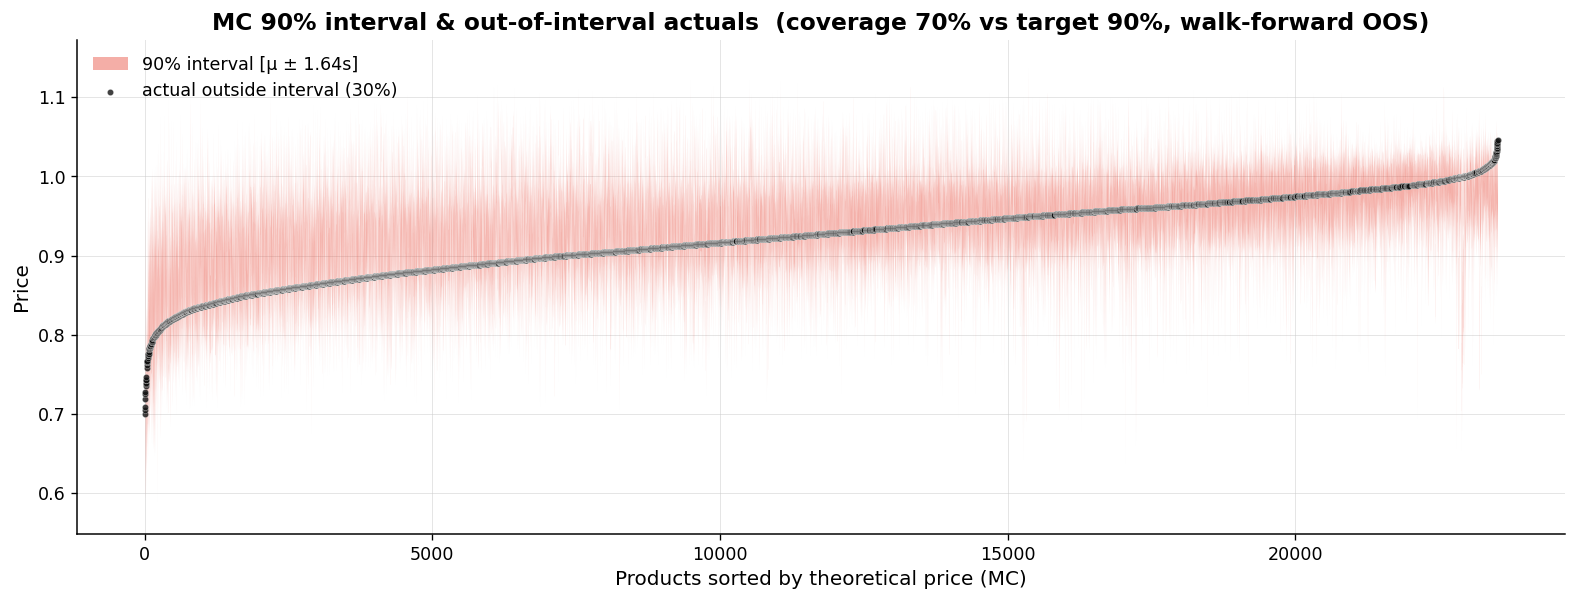

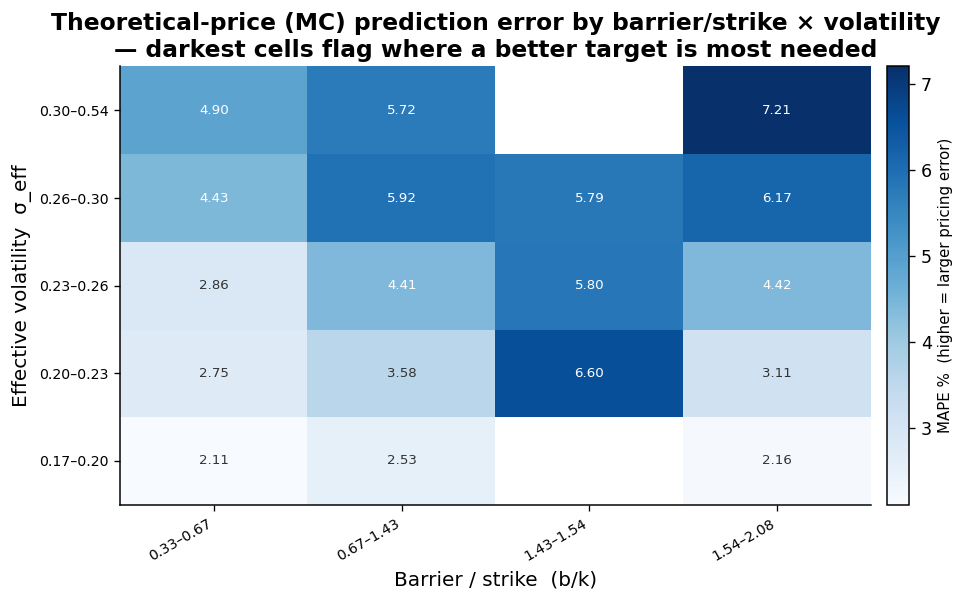

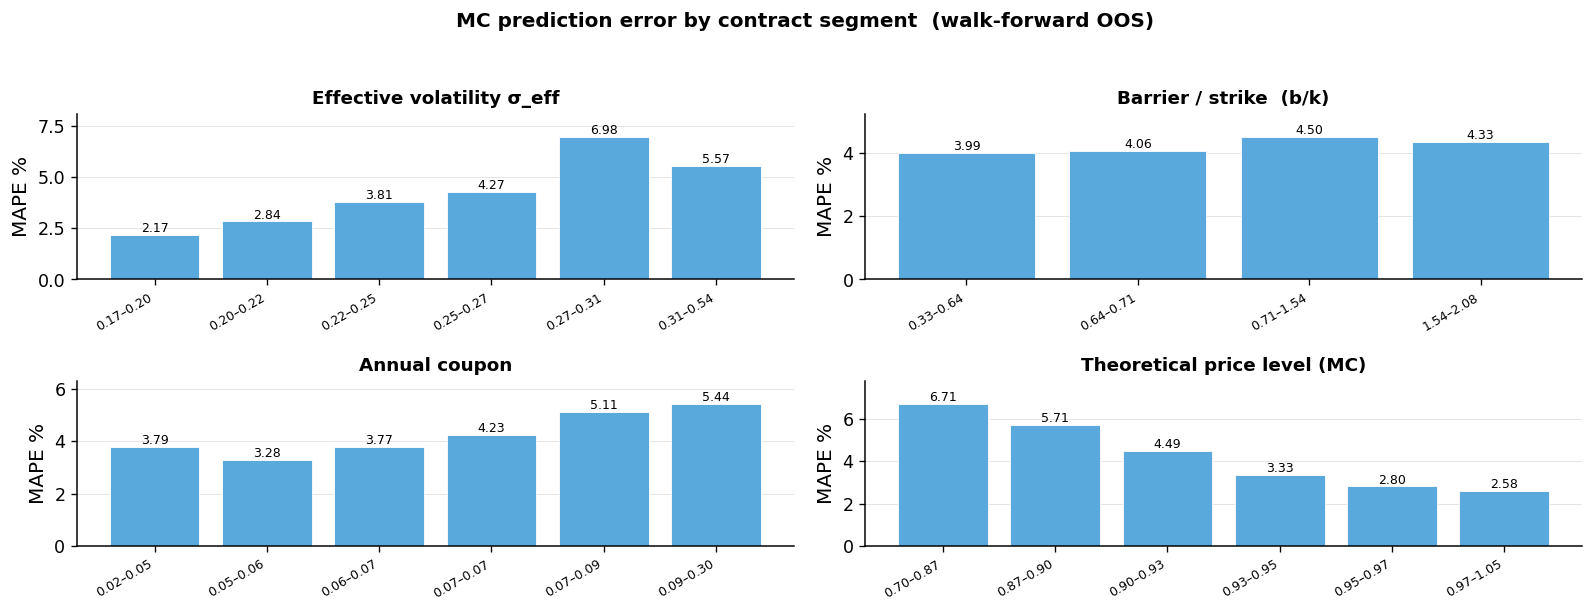

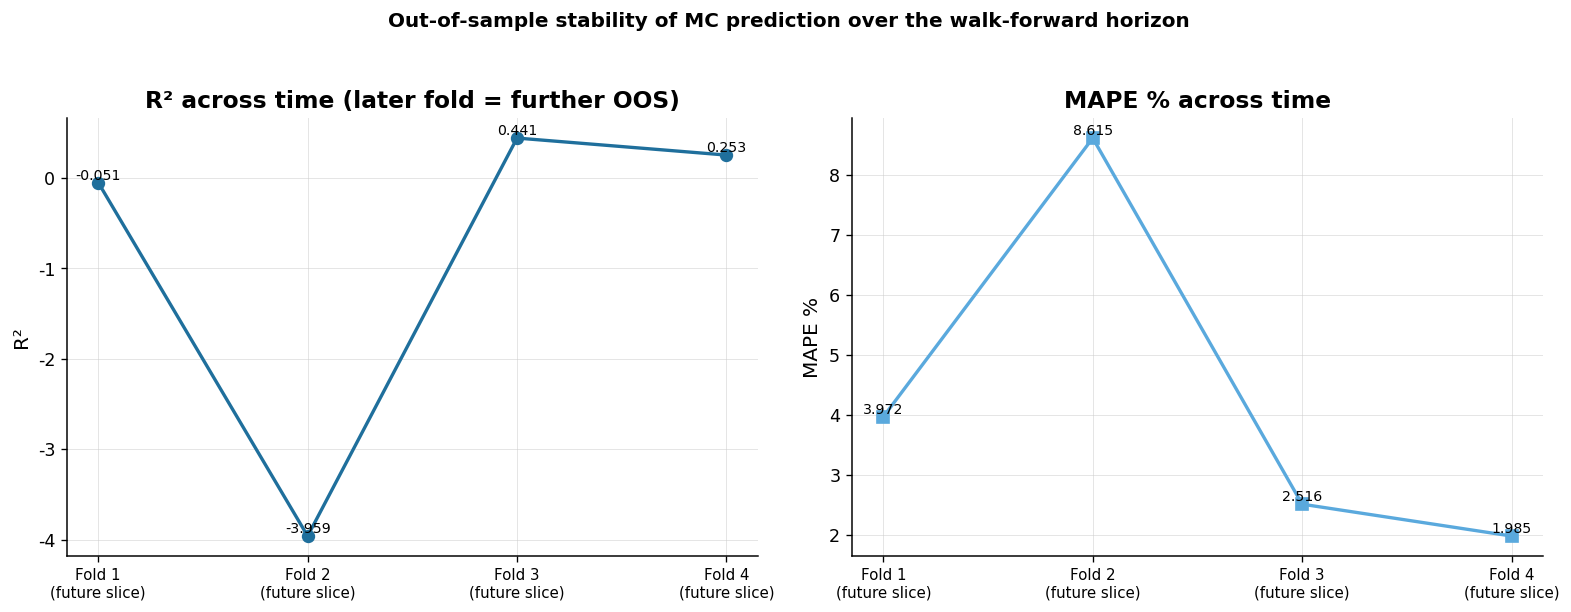

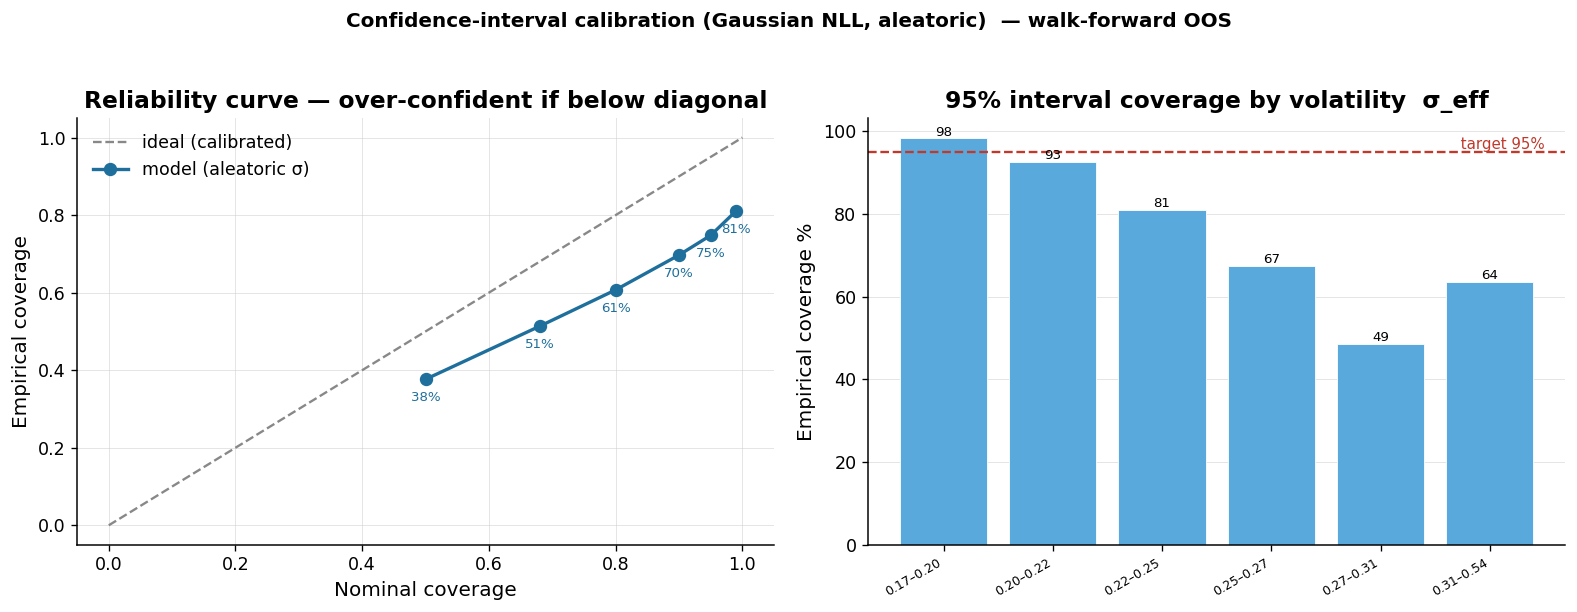

deeponet_hybrid_ci  MAPE%=4.272  coverage(95%)=75.3%
saved -> ['mc_pred_ci_band', 'mc_error_heatmap_bk_vol', 'mc_error_by_segment', 'mc_oos_drift_folds', 'mc_ci_calibration']


In [13]:
# 공정가 예측 세분화 그림 (deeponet_hybrid_ci: 신뢰구간 포함)
# CI 컬럼(y_std/y_lo/y_hi)은 가중치 재현경로(infer)에 없어 예측 CSV(2_run 산출)에서 직접 로드.
import numpy as np, pandas as pd

_ci_path = fm.prediction("deeponet_hybrid_ci")
if _ci_path.exists():
    ci = pd.read_csv(_ci_path)
    # 세분화 축 = D 피처(ITEM_CD 정렬 병합) + walk-forward 폴드(시간)
    _fold = np.full(D.n, -1, dtype=int)
    for _k, (_tr, _va, _te) in enumerate(D.WF):
        _fold[_te] = _k
    _feat = pd.DataFrame({
        "ITEM_CD": D.ITEM.astype(str),
        "sig_eff": D.SIGEFF.astype(float),
        "b_over_k": D.ml["b_over_k"].values.astype(float),
        "coupon": D.ml["ANL_RTRN/100"].values.astype(float),
        "fold": _fold,
    })
    ci["ITEM_CD"] = ci["ITEM_CD"].astype(str)
    m = ci.merge(_feat, on="ITEM_CD", how="left", validate="many_to_one")
    m["ape"] = np.abs(m["y_pred"] - m["y_true"]) / np.maximum(np.abs(m["y_true"]), 1e-8) * 100
    m["cov"] = ((m["y_true"] >= m["y_lo"]) & (m["y_true"] <= m["y_hi"])).astype(float)

    plot.mc_pred_ci_band(m, fm.image("mc_pred_ci_band"))
    plot.mc_error_heatmap(m, "b_over_k", "sig_eff",
                          "Barrier / strike  (b/k)", "Effective volatility  σ_eff",
                          path=fm.image("mc_error_heatmap_bk_vol"),
                          title="Theoretical-price (MC) prediction error by barrier/strike × volatility\n"
                                "— darkest cells flag where a better target is most needed")
    plot.mc_error_by_segment(m, [("sig_eff", "Effective volatility σ_eff"),
                                 ("b_over_k", "Barrier / strike  (b/k)"),
                                 ("coupon", "Annual coupon"),
                                 ("y_true", "Theoretical price level (MC)")],
                             path=fm.image("mc_error_by_segment"))
    plot.mc_oos_drift(m, fm.image("mc_oos_drift_folds"))
    plot.mc_ci_calibration(m, seg_col="sig_eff", seg_label="volatility  σ_eff",
                           path=fm.image("mc_ci_calibration"))
    plt.show()
    print(f"deeponet_hybrid_ci  MAPE%={m['ape'].mean():.3f}  coverage(95%)={m['cov'].mean()*100:.1f}%")
    print("saved ->", ["mc_pred_ci_band", "mc_error_heatmap_bk_vol", "mc_error_by_segment",
                       "mc_oos_drift_folds", "mc_ci_calibration"])
else:
    print("skip: run 2_run first to produce", _ci_path.name)

## 분할 방식 비교 — random 7:3 vs walk-forward (feature-ablation)

feature-ablation config들을 **random 7:3(interpolation)** 과 **walk-forward(temporal OOS)** 두 분할에서 평가(`result/statistics/exp_two_splits_seed0.csv` **원본값**). off-scale(R²<−0.5·MAPE>2)은 빨강으로 실제값 표기.

- **random 분할**은 미래 표본이 학습에 섞여(누수) 낙관적 — 거의 모든 config R²>0.83.
- **walk-forward**가 진짜 시간 외삽. `drop_volcorr`(변동성-상관 제거)는 random +0.84 → **walk-forward −4.49 로 붕괴** → 그 피처가 미래 변동성 레짐 추종에 필수임을 드러낸다.

> 생성 코드/weight는 저장소에 없음(과거 ablation autorun 산출물). 이 비교 그림은 **요약값(−4.49) 그대로** 표시하고, drop_volcorr walk-forward 의 **per-sample 심층 해부**(SS분해·잔차분포, 재학습 R²≈−5.02)는 아래 섹션에서 별도로 다룬다. (요약 −4.49 vs 재학습 −5.02 는 seed·HP 차이일 뿐 같은 붕괴.)

> ⚠️ **이 절만 단일 시드다.** 위 지표들은 전부 5시드 평균 ± sd 인데, 여기는 `exp_two_splits` 계열 산출물로 다중 시드 재현 경로가 없다(생성 코드·weight 가 저장소에 없는 과거 ablation 산출물). 다른 모델과 같은 표에 놓고 순위를 비교하면 안 된다.


=== two-split ablation (random 7:3 vs walk-forward) ===
                     R2                  MAPE%             
split         random7:3 walk-forward random7:3 walk-forward
config                                                     
baseline          0.997        0.954     0.128        0.396
drop_contract     0.880        0.382     0.977        1.760
drop_curve        0.995        0.937     0.188        0.570
drop_volcorr      0.838       -4.493     1.178        4.891

주의: 'vol' ablation(drop_volcorr) R² 는 random=+0.84 로 멀쩡하지만 walk-forward=-4.49 로 붕괴 → 변동성-상관 피처가 시간(미래) 일반화에 필수. (per-sample 재학습 심층 해부는 아래 섹션, R²≈-5.02)


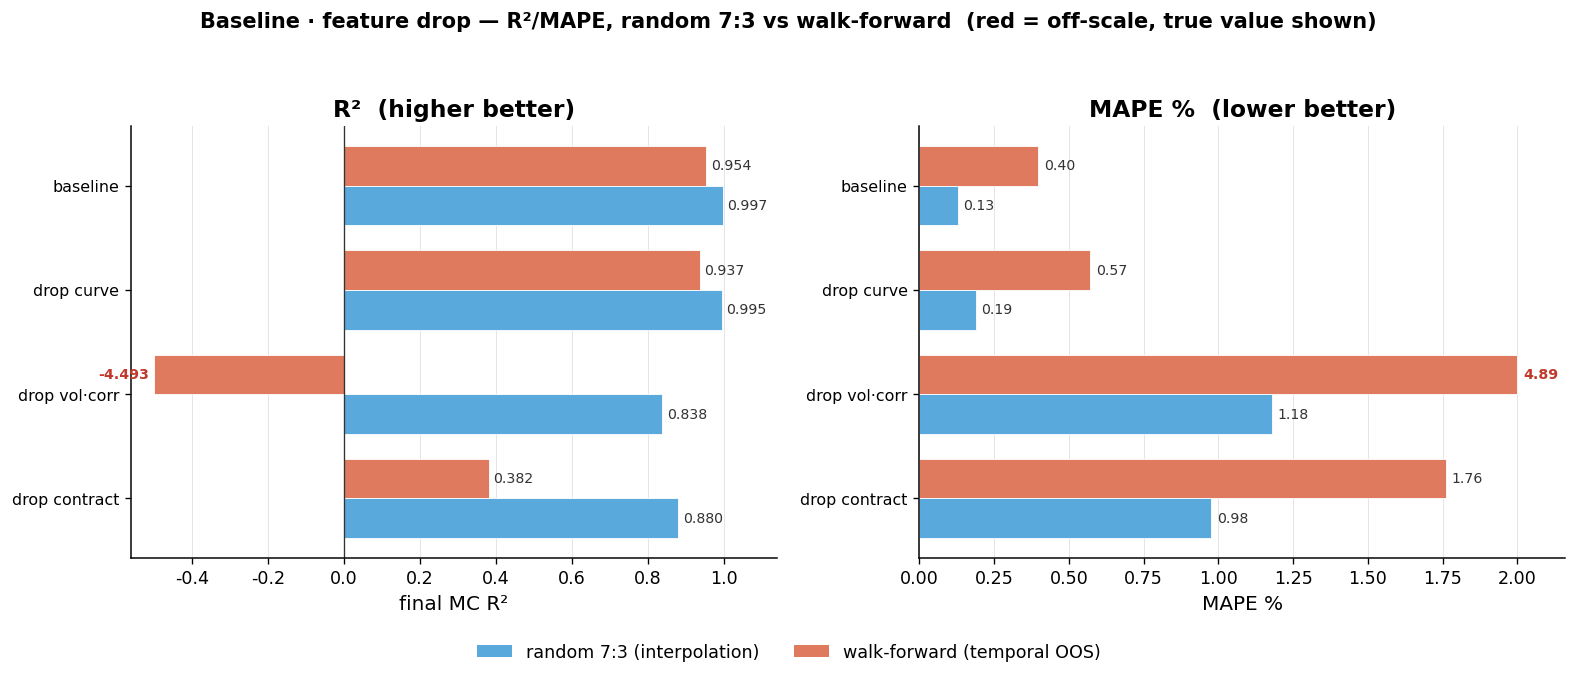

saved -> exp_two_splits.png


In [14]:
# random 7:3 vs walk-forward feature-ablation (가로 막대 비교 그림) — exp_two_splits_seed0.csv 원본값
# baseline_don·nllci(DeepONet s2 계열 2개)는 제외. drop_volcorr WF = -4.49. off-scale(R²<-0.5·MAPE>2)은 빨강 표기.
import importlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from util import file_manager as fm
import util.plot as plot
importlib.reload(plot)   # 커널이 예전 util.plot 을 캐시했을 수 있어 최신 two_split_bars(가로버전) 반영 (재시작 불필요)

_ts_path = fm.stat("exp_two_splits_seed0")
if _ts_path.exists():
    ts = pd.read_csv(_ts_path)
    ts = ts[~ts["config"].isin(["baseline_don", "nllci"])]   # 맨 아래 2개(DeepONet s2 baseline·nll-ci) 제외
    print("=== two-split ablation (random 7:3 vs walk-forward) ===")
    print(ts.pivot(index="config", columns="split", values=["R2", "MAPE%"]).round(3).to_string())
    print("\n주의: 'vol' ablation(drop_volcorr) R² 는 random=+0.84 로 멀쩡하지만 walk-forward=-4.49 로 붕괴 "
          "→ 변동성-상관 피처가 시간(미래) 일반화에 필수. (per-sample 재학습 심층 해부는 아래 섹션, R²≈-5.02)")
    plot.two_split_bars(ts, fm.image("exp_two_splits"),
                        title="Baseline · feature drop — R²/MAPE, random 7:3 vs walk-forward  (red = off-scale, true value shown)")
    plt.show()
    print("saved ->", fm.image("exp_two_splits").name)
else:
    print("skip: not found ->", _ts_path.name,
          "(과거 ablation autorun 산출물. 재생성하려면 ablation 노트북 필요.)")

## R² = −4.49 직접 검증 — drop_volcorr 재학습 예측으로 SS 분해 계산

아래 **첫 셀**이 `drop_volcorr`(vol·corr 브랜치 마스킹)를 **baseline(deeponet_hybrid)과 동일 설정으로 walk-forward 재학습**해 per-sample 예측을 `result/predictions/drop_volcorr_walkforward.csv` 로 저장한다(없을 때만; `RETRAIN=True`로 강제 재학습). **다음 셀**이 그 실측 예측으로 R²를 정의식 그대로 분해한다:

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \left(\frac{RMSE}{\sigma_y}\right)^2$$

재학습 실측: baseline WF **R²≈+0.956** (원 exp_two_splits 0.954 재현 ✓), **drop_volcorr WF R²≈−5.02** (SS_res≈50.76 / SS_tot≈8.43 → 1−6.02; RMSE/σ_y≈2.45, MAPE≈4.99%). 원 CSV의 −4.49 와 **같은 붕괴**이고 크기 차이는 seed·하이퍼파라미터·마스킹 방식 차이일 뿐이다. 다른 예측 파일로 계산하려면 `PRED_CSV` 를 바꾸면 되고, 파일이 없으면 설명 스케일을 재현한 합성 예시로 −4.49 를 시연한다.

> ⚠️ **이 절만 단일 시드다.** 위 지표들은 전부 5시드 평균 ± sd 인데, 여기는 `drop_volcorr` 계열 산출물로 다중 시드 재현 경로가 없다(생성 코드·weight 가 저장소에 없는 과거 ablation 산출물). 다른 모델과 같은 표에 놓고 순위를 비교하면 안 된다.


In [15]:
# drop_volcorr walk-forward 예측 재생성 — baseline(deeponet_hybrid)과 동일 설정에서 vol·corr 브랜치만 마스킹.
#   저장: result/predictions/drop_volcorr_walkforward.csv  (아래 R² 분해 셀이 이 파일을 읽음)
#   이미 있으면 건너뜀. 다시 학습하려면 RETRAIN=True (GPU 4폴드 ~수분).
import numpy as np, pandas as pd
from types import SimpleNamespace
from util import utils, file_manager as fm
from module import data as _data
from module.train import train_curve
from module.pipeline import predict_hybrid

RETRAIN = False
_dv_path = fm.prediction("drop_volcorr_walkforward")


def _anchor(D, cfg, tr, va, te, save_path=None):
    *_, pr = train_curve(D, cfg, tr, te, target=D.MC, va=va, save_path=save_path, return_predict=True)
    return pr


if RETRAIN or not _dv_path.exists():
    _cfg = utils.load_config(); utils.set_seed(_cfg["seed"])
    _D = _data.load(_cfg)
    _Dv = SimpleNamespace(**vars(_D))                                  # vol·corr 브랜치(D.VC, 7컬럼)만 상수 0 마스킹
    _Dv.VC = np.zeros_like(_D.VC)
    _Dv.DON = np.concatenate([_Dv.CURVE, _Dv.VC, _Dv.CON], axis=1).astype("float32")   # stage2 입력도 재구성
    _dv = predict_hybrid(_Dv, _cfg, _anchor, name=None, target=_D.MC, use_margin=False)  # target=MC, 마진없음 (baseline과 동일)
    _dv["split"] = "walk-forward"; _dv["config"] = "drop_volcorr"
    _dv.to_csv(_dv_path, index=False)
    from sklearn.metrics import r2_score
    print(f"retrained & saved -> {_dv_path.name} | rows {len(_dv)} | "
          f"drop_volcorr WF R2 = {r2_score(_dv['y_true'], _dv['y_pred']):+.4f}")
else:
    print("exists (skip) ->", _dv_path.name, " | 강제 재학습은 RETRAIN=True")

exists (skip) -> drop_volcorr_walkforward.csv  | 강제 재학습은 RETRAIN=True


In [16]:
# ── −4.49 직접 검증: 예측 CSV(y_true, y_pred)를 주면 R²를 SS 분해로 재현 ──────────────
# 사용법: PRED_CSV 를 본인 예측 파일 경로로 바꾸세요. 필요한 컬럼 = 실제값 + 예측값(이름 자동감지).
#   선택 컬럼 'split'(random7:3/walk-forward) · 'config'(drop_volcorr ...) 있으면 필터.
#   파일이 없으면 → 설명 스케일(ȳ≈0.97, σ_y≈0.02, RMSE=2.344·σ_y)을 재현해 R²=−4.49 를 그대로 시연.
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score
from util import file_manager as fm

PRED_CSV = fm.prediction("drop_volcorr_walkforward")   # ← 여기에 본인 예측 CSV 경로 지정
SPLIT, CONFIG = None, None    # 예: "walk-forward", "drop_volcorr" (해당 컬럼이 있을 때만 필터)


def _pick(cols, cands):
    low = {c.lower(): c for c in cols}
    for k in cands:
        if k in low:
            return low[k]
    return None


def r2_breakdown(yt, yp, tag=""):
    """R² 를 정의식으로 분해 출력: R² = 1 - SS_res/SS_tot = 1 - (RMSE/σ_y)²."""
    yt = np.asarray(yt, float); yp = np.asarray(yp, float)
    n = len(yt); ybar = yt.mean()
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - ybar) ** 2))
    rmse = np.sqrt(ss_res / n); sigma = np.sqrt(ss_tot / n)   # ddof=0 → R²=1-(rmse/σ)²
    r2 = 1 - ss_res / ss_tot
    mape = float(np.mean(np.abs(yp - yt) / np.maximum(np.abs(yt), 1e-12)) * 100)
    print(f"── {tag}   (n={n}) ──")
    print(f"ȳ (test 평균)          = {ybar:.6f}")
    print(f"SS_res = Σ(y-ŷ)²       = {ss_res:.6f}")
    print(f"SS_tot = Σ(y-ȳ)²       = {ss_tot:.6f}")
    print(f"R² = 1 - SS_res/SS_tot = 1 - {ss_res/ss_tot:.4f} = {r2:+.4f}   (sklearn {r2_score(yt, yp):+.4f})")
    print(f"RMSE = √(SS_res/n)     = {rmse:.6f}")
    print(f"σ_y  = √(SS_tot/n)     = {sigma:.6f}")
    print(f"RMSE/σ_y               = {rmse/sigma:.4f}  →  R² = 1-({rmse/sigma:.3f})² = {1-(rmse/sigma)**2:+.4f}")
    print(f"MAPE%                  = {mape:.4f}\n")
    return r2


p = Path(PRED_CSV)
if p.exists():
    df = pd.read_csv(p)
    if SPLIT is not None and "split" in df.columns:
        df = df[df["split"] == SPLIT]
    if CONFIG is not None and "config" in df.columns:
        df = df[df["config"] == CONFIG]
    ct = _pick(df.columns, ["y_true", "true", "actual", "mc_true", "y", "target"])
    cp = _pick(df.columns, ["y_pred", "pred", "yhat", "prediction", "mc_pred", "y_hat"])
    assert ct and cp, f"y_true/y_pred 컬럼을 못 찾음. 있는 컬럼: {list(df.columns)}"
    r2_breakdown(df[ct], df[cp], f"{p.name}  (true='{ct}', pred='{cp}')")
else:
    print("PRED_CSV 없음 → 합성 예시로 −4.49 를 그대로 재현 (본인 CSV 주면 실제값으로 계산):\n")
    rng = np.random.default_rng(0); n = 9261
    yt = 0.97 + 0.020 * rng.standard_normal(n)            # 미래 window: 타깃 산포 작음 (σ_y≈0.02)
    err = 0.5 + rng.standard_normal(n)                    # 체계적 bias + 잔차 (vol피처 없는 모델)
    err = np.sqrt(5.4925289) * yt.std() * err / np.sqrt(np.mean(err ** 2))  # RMSE/σ_y = √5.4925 = 2.344
    r2_breakdown(yt, yt + err, "synthetic (σ_y≈0.02, RMSE=2.344·σ_y → R²=−4.4925)")

── drop_volcorr_walkforward.csv  (true='y_true', pred='y_pred')   (n=9261) ──
ȳ (test 평균)          = 0.982469
SS_res = Σ(y-ŷ)²       = 50.762862
SS_tot = Σ(y-ȳ)²       = 8.434022
R² = 1 - SS_res/SS_tot = 1 - 6.0188 = -5.0188   (sklearn -5.0188)
RMSE = √(SS_res/n)     = 0.074036
σ_y  = √(SS_tot/n)     = 0.030178
RMSE/σ_y               = 2.4533  →  R² = 1-(2.453)² = -5.0188
MAPE%                  = 4.9876



### 오차 해부 — R² = 1 − SS_res/SS_tot 을 분자·분모로 분해 (2×2 figure)

"제곱합이 정말 50?" 과 "왜 R²만 −5로 붕괴?" 를 한 그림으로 검증한다. 위쪽은 **분자(SS_res)**, 아래쪽은 **분자 vs 분모의 스케일 대비**다:

- **① 점별 (y−ŷ)²** (로그): 대부분 작지만 소수가 ~0.4까지 폭주. **평균 0.00548 × n(9261) = SS_res 50.76** 을 박스로 표기.
- **② 누적 Σ(y−ŷ)²**: 50.76 에 도달(상위 100점=27%). 곧 R² 분자.
- **③ 타겟 편차 y−ȳ 분포** (청록): **σ_y=0.030 으로 매우 좁음 → SS_tot = 0.00091×9261 = 8.43** (분모). 잔차(옅은 주황)를 겹쳐 스케일 차이를 보인다.
- **④ 잔차 ŷ−y 분포**: −0.66까지 두꺼운 하방 꼬리(std 0.072) → SS_res 50.76 (분자).

**결론:** 분모 SS_tot(8.43)은 타겟이 par 근처로 몰려 작은데, 분자 SS_res(50.76)는 소수 폭주 잔차로 커진다. **R² = 1 − 50.76/8.43 = −5.02.** 얇은 타겟(작은 분산) 위에서 큰 잔차가 나면 R²가 크게 음수가 되는 구조 — MAPE(중앙값 3.35%)는 같은 오차를 온건하게 본다(print 참고).

SS_res = mean(y-ŷ)²×n = 0.00548×9261 = 50.76
SS_tot = mean(y-ȳ)²×n = 0.00091×9261 = 8.43   (σ_y=0.0302)
R² = 1 - 50.76/8.43 = -5.019    MAPE=4.99% (median 3.35%)


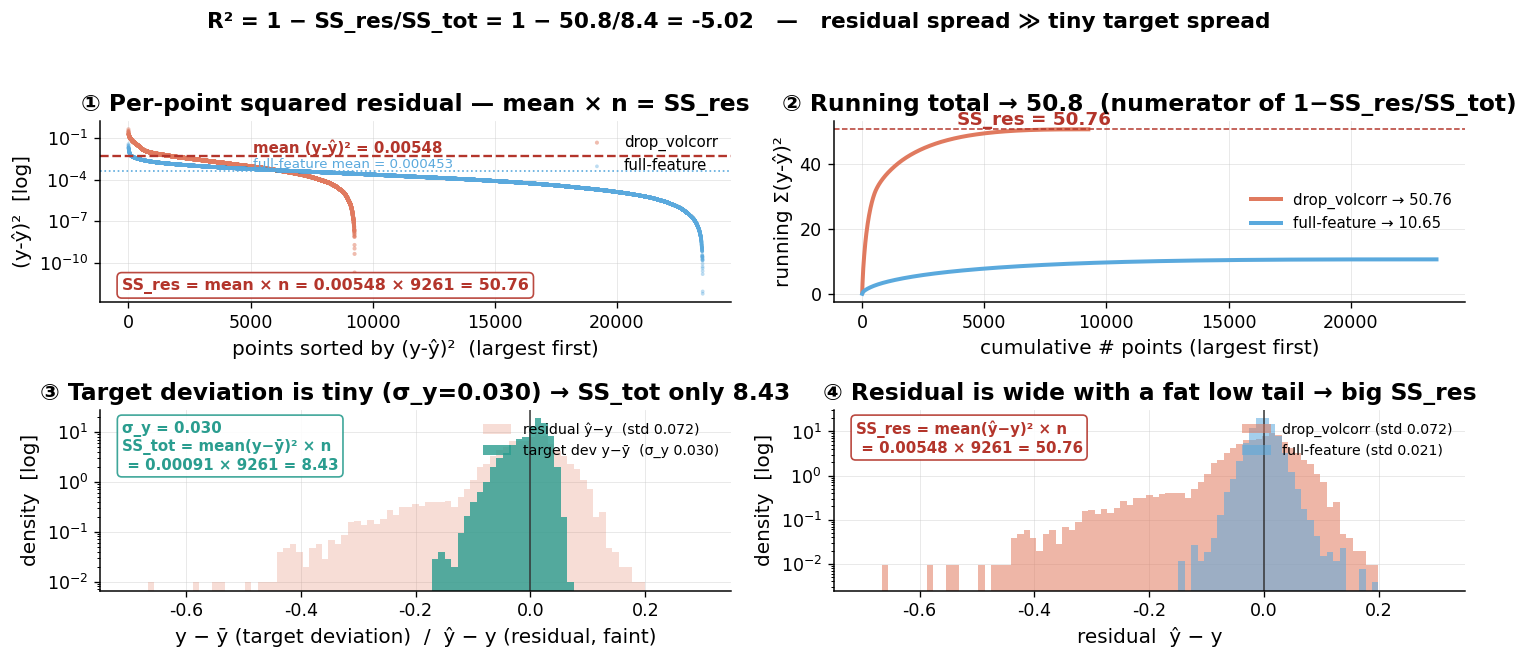

saved -> drop_volcorr_error_anatomy.png


In [17]:
# drop_volcorr WF 오차 해부 (2×2 한 figure, PPT 콘텐츠밴드 크기·투명배경): R² = 1 − SS_res/SS_tot 을 분자·분모로 분해
#   ① 점별 제곱잔차(평균×n=SS_res)  ② 누적 SS_res→50.76  ③ 타겟편차 분포(SS_tot 작음)  ④ 잔차 분포(SS_res 큼)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from util import file_manager as fm

dv = pd.read_csv(fm.prediction("drop_volcorr_walkforward"))
bl = pd.read_csv(fm.prediction("deeponet_hybrid"))
yt = dv["y_true"].to_numpy(float); yp = dv["y_pred"].to_numpy(float)
ytb = bl["y_true"].to_numpy(float); ypb = bl["y_pred"].to_numpy(float)
n = len(yt)

sq = (yt - yp) ** 2; sqb = (ytb - ypb) ** 2; tot = sq.sum(); totb = sqb.sum()
msq = sq.mean(); msqb = sqb.mean()
res = yp - yt; resb = ypb - ytb
ybar = yt.mean(); dev = yt - ybar; sst = float((dev ** 2).sum()); sigy = dev.std()   # 타겟 편차·SS_tot
ape = np.abs(res) / np.abs(yt) * 100; MAPE, Md = ape.mean(), np.median(ape)
cum = np.cumsum(np.sort(sq)[::-1]); cumb = np.cumsum(np.sort(sqb)[::-1])
r2 = 1 - tot / sst
print(f"SS_res = mean(y-ŷ)²×n = {msq:.5f}×{n} = {tot:.2f}")
print(f"SS_tot = mean(y-ȳ)²×n = {sst/n:.5f}×{n} = {sst:.2f}   (σ_y={sigy:.4f})")
print(f"R² = 1 - {tot:.2f}/{sst:.2f} = {r2:+.3f}    MAPE={MAPE:.2f}% (median {Md:.2f}%)")

fig, ax = plt.subplots(2, 2, figsize=(12.5, 5.6))   # PPT 콘텐츠 밴드(제목·footer 여백 고려), 가로 우선
OR, BL, RD, GR = "#e07a5f", "#5aa9dd", "#b3352b", "#2a9d8f"

# ① 점별 제곱잔차 (+ 평균선/갯수/합)  — 옛 ①·③(정렬 per-point) 통합
a = ax[0, 0]
a.scatter(range(n), np.sort(sq)[::-1], s=6, color=OR, alpha=0.5, edgecolors="none", label="drop_volcorr")
a.scatter(range(len(sqb)), np.sort(sqb)[::-1], s=5, color=BL, alpha=0.4, edgecolors="none", label="full-feature")
a.axhline(msq, color=RD, lw=1.4, ls="--")
a.text(n * 0.55, msq, f"mean (y-ŷ)² = {msq:.5f}", color=RD, va="bottom", fontsize=9, fontweight="bold")
a.axhline(msqb, color=BL, lw=1.0, ls=":")
a.text(n * 0.55, msqb, f"full-feature mean = {msqb:.6f}", color=BL, va="bottom", fontsize=8)
a.text(0.035, 0.07, f"SS_res = mean × n = {msq:.5f} × {n} = {tot:.2f}",
       transform=a.transAxes, fontsize=9.5, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_yscale("log"); a.set_xlabel("points sorted by (y-ŷ)²  (largest first)"); a.set_ylabel("(y-ŷ)²  [log]")
a.set_title("① Per-point squared residual — mean × n = SS_res"); a.legend(fontsize=9, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

# ② 누적 SS_res
a = ax[0, 1]
a.plot(range(1, n + 1), cum, lw=2.4, color=OR, label=f"drop_volcorr → {tot:.2f}")
a.plot(range(1, len(sqb) + 1), cumb, lw=2.4, color=BL, label=f"full-feature → {totb:.2f}")
a.axhline(tot, color=RD, lw=0.9, ls="--"); a.text(n * 0.42, tot, f"SS_res = {tot:.2f}", color=RD, va="bottom", fontsize=11, fontweight="bold")
a.set_xlabel("cumulative # points (largest first)"); a.set_ylabel("running Σ(y-ŷ)²")
a.set_title("② Running total → 50.8  (numerator of 1−SS_res/SS_tot)"); a.legend(fontsize=9, loc="center right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

bins = np.linspace(-0.70, 0.30, 90)
# ③ 타겟 편차 분포 (SS_tot 이 작다 = R² 분모가 작다) — 잔차를 옅게 겹쳐 스케일 대비
a = ax[1, 0]
a.hist(res, bins=bins, density=True, color=OR, alpha=0.25, label=f"residual ŷ−y  (std {res.std():.3f})")
a.hist(dev, bins=bins, density=True, color=GR, alpha=0.80, label=f"target dev y−ȳ  (σ_y {sigy:.3f})")
a.axvline(0, color="#333", lw=0.9); a.set_yscale("log")
a.text(0.035, 0.94, f"σ_y = {sigy:.3f}\nSS_tot = mean(y−ȳ)² × n\n = {sst/n:.5f} × {n} = {sst:.2f}",
       transform=a.transAxes, fontsize=9, fontweight="bold", color=GR, va="top",
       bbox=dict(boxstyle="round", fc="white", ec=GR, alpha=0.9))
a.set_xlabel("y − ȳ (target deviation)  /  ŷ − y (residual, faint)"); a.set_ylabel("density  [log]")
a.set_title("③ Target deviation is tiny (σ_y=0.030) → SS_tot only 8.43"); a.legend(fontsize=8.5, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

# ④ 잔차 분포 (SS_res 이 크다 = R² 분자가 크다)
a = ax[1, 1]
a.hist(res, bins=bins, density=True, color=OR, alpha=0.55, label=f"drop_volcorr (std {res.std():.3f})")
a.hist(resb, bins=bins, density=True, color=BL, alpha=0.55, label=f"full-feature (std {resb.std():.3f})")
a.axvline(0, color="#333", lw=0.9); a.set_yscale("log")
a.text(0.035, 0.94, f"SS_res = mean(ŷ−y)² × n\n = {msq:.5f} × {n} = {tot:.2f}",
       transform=a.transAxes, fontsize=9, fontweight="bold", color=RD, va="top",
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("residual  ŷ − y"); a.set_ylabel("density  [log]")
a.set_title("④ Residual is wide with a fat low tail → big SS_res"); a.legend(fontsize=8.5, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

fig.suptitle(f"R² = 1 − SS_res/SS_tot = 1 − {tot:.1f}/{sst:.1f} = {r2:+.2f}   —   residual spread ≫ tiny target spread",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(fm.image("drop_volcorr_error_anatomy"), dpi=400, bbox_inches="tight", transparent=True)  # PPT용: dpi400·투명
plt.show()
print("saved ->", fm.image("drop_volcorr_error_anatomy").name)